**多臂老虎机**

不存在状态信息，只有动作和奖励

在各根杠杆的奖励都未知的情况下，在操作 T 次后获得尽可能高的累计奖励

**通过估计期望奖励进行决策**

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [1]:
class BernoulliBandit:
    """伯努利多臂老虎机,输入K表示拉杆个数"""
    def __init__(self, K):
        
        self.probs = np.random.uniform(size=K) # 随机生成K个[0,1]均匀分布数，作为每根拉杆中奖概率        
        self.best_idx = np.argmax(self.probs) # 概率最大的拉杆编号
        self.best_prob = self.probs[self.best_idx]
        self.K = K

    def step(self, k):
        """拉动k号拉杆，返回奖励"""
        if np.random.rand() < self.probs[k]:
            return 1
        else:
            return 0

In [3]:
np.random.seed(1)
K = 10
bandit = BernoulliBandit(K)

In [4]:
class Solver:
    """多臂老虎机算法基本框架 """
    def __init__(self, bandit):
        self.bandit = bandit          # 绑定老虎机环境
        self.counts = np.zeros(self.bandit.K) # 每根拉杆被尝试的总次数 N_k
        self.regret = 0.              # 当前累计懊悔
        self.actions = []             # 记录每一步选择的拉杆序列
        self.regrets = []             # 记录每一步后的累计懊悔

    def update_regret(self, k):
        """更新并保存累计懊悔"""
        # 单步懊悔 = 最优期望奖励 - 当前选择拉杆的期望奖励
        self.regret += self.bandit.best_prob - self.bandit.probs[k]
        self.regrets.append(self.regret)

    def run_one_step(self):
        """返回当前要选的拉杆k"""
        raise NotImplementedError

    def run(self, num_steps):
        """循环运行num_steps次交互"""
        for _ in range(num_steps):
            # 策略选出动作
            k = self.run_one_step()
            # 更新该拉杆被选择次数
            self.counts[k] += 1
            # 保存动作轨迹
            self.actions.append(k)
            # 计算懊悔
            self.update_regret(k)

**$\epsilon - \text{Greedy}$ 算法**

以 $1 - \epsilon$ 的概率选取期望奖励最大的杠杆，$\epsilon$ 的概率随机选取一根杠杆

In [5]:
class EpsilonGreedy(Solver):
    """ epsilon贪心算法,继承Solver类 """

    def __init__(self, bandit, epsilon=0.01, init_prob=1.0):
        super(EpsilonGreedy, self).__init__(bandit)
        self.epsilon = epsilon
        self.estimates = np.array([init_prob] * self.bandit.K) # 初始化拉动所有拉杆的期望奖励估值（乐观初始值技巧）

    def run_one_step(self):
        if np.random.random() < self.epsilon:
            k = np.random.randint(0, self.bandit.K)  # 随机选择一根拉杆
        else:
            k = np.argmax(self.estimates)  # 选择期望奖励估值最大的拉杆
        
        r = self.bandit.step(k)            # 得到本次动作的奖励
        self.estimates[k] += 1. / (self.counts[k] + 1) * (r - self.estimates[k])
        return k

In [6]:
def plot_results(solvers, solver_names):
    """
    生成累积懊悔随时间变化的图像
    输入solvers是一个列表,列表中的每个元素是一种特定的策略
    而solver_names也是一个列表,存储每个策略的名称
    """
    for idx, solver in enumerate(solvers):
        time_list = range(len(solver.regrets))
        plt.plot(time_list, solver.regrets, label=solver_names[idx])
    
    plt.xlabel('Time steps')
    plt.ylabel('Cumulative regrets')
    plt.title('%d-armed bandit' % solvers[0].bandit.K)
    plt.legend()
    plt.show()


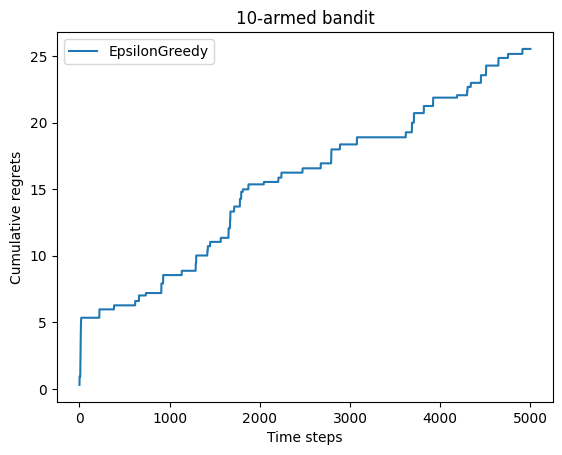

In [16]:
np.random.seed(1)
epsilon_greedy_solver = EpsilonGreedy(bandit, epsilon=0.01)
epsilon_greedy_solver.run(5000)
plot_results([epsilon_greedy_solver], ["EpsilonGreedy"])

由于总是会有随机选取的行为，所有累计遗憾必然会线性增加

**解决方案：让 $\epsilon$ 随时间的增加减小** \
常用的缩减函数为 $\epsilon_t = \frac{1}{t}$

In [22]:
class DecayingEpsilonGreedy(Solver):
    """ epsilon值随时间衰减的epsilon-贪婪算法,继承Solver类 """
    
    def __init__(self, bandit, init_prob=1.0):
        super(DecayingEpsilonGreedy, self).__init__(bandit)
        self.estimates = np.array([init_prob] * self.bandit.K)
        self.total_count = 0

    def run_one_step(self):
        self.total_count += 1
        epsilon = 10 / np.sqrt(self.total_count)
        if np.random.random() < epsilon:
            k = np.random.randint(0, self.bandit.K)  # 探索：随机拉杆
        else:
            k = np.argmax(self.estimates)            # 利用：选择估值最大拉杆

        r = self.bandit.step(k)

        self.estimates[k] += 1. / (self.counts[k] + 1) * (r - self.estimates[k])
        return k

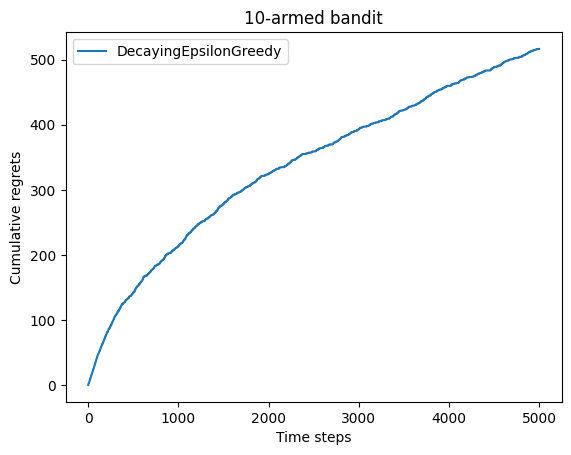

In [23]:
np.random.seed(1)
decaying_epsilon_greedy_solver = DecayingEpsilonGreedy(bandit)
decaying_epsilon_greedy_solver.run(5000)
plot_results([decaying_epsilon_greedy_solver], ["DecayingEpsilonGreedy"])

**上置信界算法**

核心：一根杠杆的不确定性越大，就越有探索价值

引入不确定性度量，其值随着该动作被尝试的此时的增加而减小\
常用的函数为：$\hat{U}(a_i) = \sqrt{\frac{\log t}{2\big(N(a_i)+1\big)}}$

则：$$a_t = \arg\max_{a\in\mathcal{A}} \Big[\hat{Q}(a) + c\cdot \hat{U}(a)\Big]$$

In [13]:
class UCB(Solver):
    """ UCB算法,继承Solver类 """

    def __init__(self, bandit, coef, init_prob=1.0):
        super(UCB, self).__init__(bandit)
        self.total_count = 0
        self.estimates = np.array([init_prob] * self.bandit.K)
        self.coef = coef

    def run_one_step(self):
        self.total_count += 1
        # 计算UCB置信上界
        ucb = self.estimates + self.coef * np.sqrt(np.log(self.total_count) / (2 * (self.counts + 1)))
        k = np.argmax(ucb) # 选出置信上界最大的拉杆
        r = self.bandit.step(k)
        self.estimates[k] += 1. / (self.counts[k] + 1) * (r - self.estimates[k])
        return k

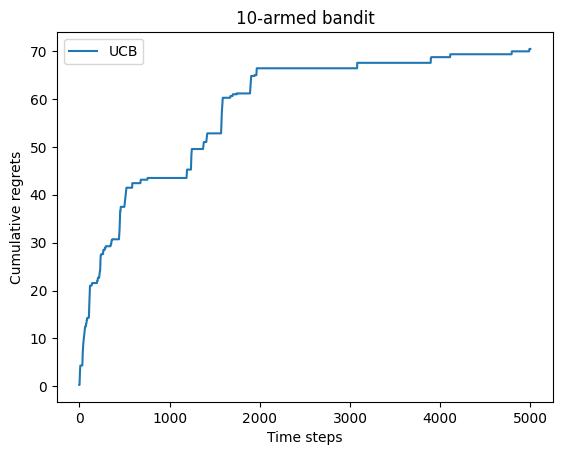

In [15]:
np.random.seed(1)
coef = 1 # 控制不确定性比重的系数
UCB_solver = UCB(bandit, coef)
UCB_solver.run(5000)
plot_results([UCB_solver], ["UCB"])

**Thompson 采样算法**

假设拉动每根杠杆的奖励服从一个特定的概率分布（在游戏过程中实时更新），根据拉动每根杠杆的期望奖励进行策略的选择

In [24]:
class ThompsonSampling(Solver):
    """ 汤普森采样算法,继承Solver类 """

    def __init__(self, bandit):
        super(ThompsonSampling, self).__init__(bandit)
        self._a = np.ones(self.bandit.K)  # 每根拉杆奖励为1的计数（Beta分布α参数）
        self._b = np.ones(self.bandit.K)  # 每根拉杆奖励为0的计数（Beta分布β参数）

    def run_one_step(self):
        samples = np.random.beta(self._a, self._b) # 按照Beta分布采样一组中奖概率样本
        k = np.argmax(samples) # 选出采样值最大的拉杆
        r = self.bandit.step(k)

        self._a[k] += r         # 更新α
        self._b[k] += (1 - r)   # 更新β
        return k


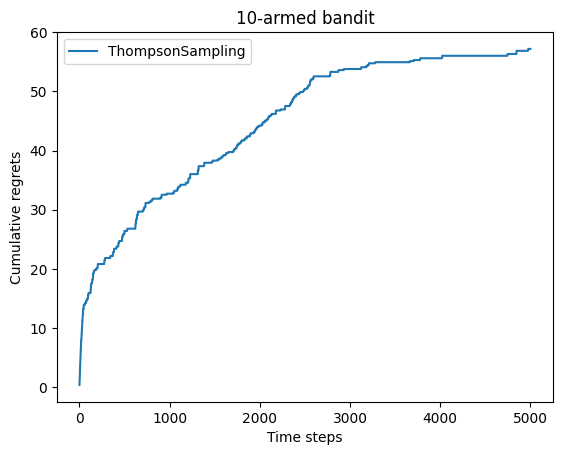

In [26]:
np.random.seed(1)
thompson_sampling_solver = ThompsonSampling(bandit)
thompson_sampling_solver.run(5000)
plot_results([thompson_sampling_solver], ["ThompsonSampling"])